# 📊 STB & STV ADR Predictive QA Analytics - Phase 1

**Objetivo:** Análisis exploratorio y feature engineering de logs STB Android

**Componentes:**
- ✅ Parsing de logs con regex
- ✅ Agrupación temporal (60s)
- ✅ Counter WEF (Warnings, Errors, Fatals)
- ✅ Feature Engineering (rates, rolling, temporal)
- ✅ Reglas de Asociación (Market Basket - Apriori)
- ✅ Visualizaciones EDA

**Output:**
- DataFrame con ~50 features → `stb_features.csv`
- Reglas de asociación → `association_rules.csv`
- Plots → `data/plots/`

**Autor:** Alberto - Senior QA Automation Engineer (Claro México)  
**Fecha:** Marzo 2026  
**Versión:** 1.0
Cuaderno para analizar logs dispositivos STB ADR
AT
carga logs en crudo en formato .txt

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from pathlib import Path 
import re
from datetime import datetime

from typing import List, Dict, Tuple
import warnings
import joblib
import os
from unittest import result

warnings.filterwarnings('ignore')

from mlxtend.frequent_patterns import apriori, association_rules

plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

OUTPUT_DIR= "../../data/processed_logs"
PLOTS_DIR= "../../data/plots"

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)

#sección import para ML
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split





In [2]:
#configuración general
log_file = "/home/at1/Desktop/qa-predictive-analytics/data/raw_logs/stb/7.3.2_v/hisense_crash_pe.txt"
#configuracion para degradación
DEGRADATION_THRESHOLD_ERROR_RATE = 0.06
DEGRADATION_THRESHOLD_FATAL = 1


#configuracion para reglas de asociación
MIN_SUPPORT = 0.05
MIN_CONFIDENCE = 0.60

#configuración tamaño de plot
PLOT_SIZE = (12, 6)
FIGSIZE_DEFAULT = (14, 7)
FIGSIZE_LARGE = (16, 8)

print(f"🔍 Configuración general:")
print(f"  - Archivo de logs: {log_file}")
print(f"  - Umbral de degradación:")
print(f"    - Error rate: {DEGRADATION_THRESHOLD_ERROR_RATE}")
print(f"    - Fatales: {DEGRADATION_THRESHOLD_FATAL}")

print(f"🔍 Configuración de reglas de asociación:")
print(f"  - Mínimo soporte: {MIN_SUPPORT}")
print(f"  - Mínimo confianza: {MIN_CONFIDENCE}")

print(f"🔍 Configuración de tamaño de plot:")
print(f"  - Tamaño predeterminado: {PLOT_SIZE}")


🔍 Configuración general:
  - Archivo de logs: /home/at1/Desktop/qa-predictive-analytics/data/raw_logs/stb/7.3.2_v/hisense_crash_pe.txt
  - Umbral de degradación:
    - Error rate: 0.06
    - Fatales: 1
🔍 Configuración de reglas de asociación:
  - Mínimo soporte: 0.05
  - Mínimo confianza: 0.6
🔍 Configuración de tamaño de plot:
  - Tamaño predeterminado: (12, 6)


In [3]:

#FUNCIÓN DE PARSEO



def read_log_file(filepath: str) -> list[dict[str, str,None]] | None:
    """Carga el archivo y retorna lista de líneas"""
    parsed_logs= []
    try:
        with open(filepath, 'r', encoding='utf-8', errors='ignore') as raw_logs:
            for line in raw_logs:
                parsed_line = parse_line(line)
                if parsed_line:
                    parsed_line["time"] = time_rounded(parsed_line["time"])
                    parsed_logs.append(parsed_line)
            return parsed_logs        

    except Exception as e:
        print(f"Error al leer el archivo TXT : {e}")
        return None
    
def parse_line(line: str) -> dict[str, str | None] | None:
    """Parsea una línea de log y retorna un diccionario con los datos"""
    if not line:
        return None
    try:
        pattern = r'^(\d{2}-\d{2})\s+(\d{2}:\d{2}:\d{2}\.\d{3})\s+(\d+)\s+(\d+)\s+([VDIWEF])\s+([^:]+):\s+(.+)$'
        match = re.match(pattern, line)
        if match:
            result = {
                "date": match.group(1),
                "time": match.group(2),
                "pid": match.group(3),
                "tid": match.group(4),
                "level": match.group(5),
                "tag": match.group(6),
                "message": match.group(7)
            }
            message = result["message"]
            
            device_match = re.search(r'model[=:]["\']*([A-Z0-9_]+)["\']*', message, re.IGNORECASE)
            if device_match:
                result["device_model"] = device_match.group(1)
            
            firmware_match = re.search(r'firmware[=:\s]+["\']*([0-9.]+)["\']*', message, re.IGNORECASE)
            if firmware_match:
                result["firmware_version"] = firmware_match.group(1)
            
            version_match = re.search(r'(?:android|version)[=:\s]+["\']*([0-9.]+)["\']*', message, re.IGNORECASE)
            if version_match:
                result["android_version"] = version_match.group(1)
            return result

        pattern_b = r'^(\d{2}-\d{2})\s+(\d{2}:\d{2}:\d{2}\.\d{3})\s+([VDIWEF])/([^(]+)\(\s*(\d+)\):\s+(.+)$'
        match = re.match(pattern_b, line)
        
        if match:
            return {
                "date": match.group(1),
                "time": match.group(2),
                "level": match.group(3),
                "tag": match.group(4).strip(),
                "pid": match.group(5).strip(),
                "tid": match.group(5).strip(),  # No hay TID en formato B, usar PID
                "message": match.group(6)
            }
        
        # No match con ningún formato
        return None   
    except Exception as e:
        print(f"Error al parsear la línea: {e}")
        return None
    
def time_rounded(parsed_line: str) -> str:
    """corta el tiempo a minutos"""
    time_minutes = datetime.strptime(parsed_line, "%H:%M:%S.%f")
    time_minutes = time_minutes.replace(second=0, microsecond=0).strftime("%H:%M")
    return time_minutes

def group_by_60s(parsed_logs: list[dict]) -> dict:
    logs_by_minute = {}
    for log in parsed_logs:
        if log['time'] not in logs_by_minute:
            logs_by_minute[log['time']] = []
        logs_by_minute[log['time']].append(log)
    return logs_by_minute

def get_claro_pids(logs_by_minute: dict) -> set:
    pattern = r'(?i)(claro|amx\.?|clarotv|launcher)'
    pids_claro = []
    for minute, logs in logs_by_minute.items():
        for log in logs:
            if re.search(pattern, log['message']):
                pids_claro.append(log['pid'])
    return set(pids_claro)

In [4]:
#funciones contadores WEF
#cuenta Warning, errores y Fatals en los logs y los suma por minuto

def counter_WEF(logs_by_minute: dict, pids_claro: set, verbose: bool = True) -> dict:
    results = {}
    tags_affected =set()
    tags_affected_claro = set()
    for minute, logs in logs_by_minute.items():
        w_all,e_all,f_all = 0,0,0
        w_claro,e_claro,f_claro = 0,0,0
        for log in logs:
            level = log['level']
            is_claro = log['pid'] in pids_claro
            if level == 'W':
                w_all += 1
                tags_affected.add(log['tag'])
                if is_claro:
                    w_claro += 1
                    tags_affected_claro.add(log['tag'])
            elif level == 'E':
                e_all += 1
                tags_affected.add(log['tag'])
                if is_claro:
                    e_claro += 1
                    tags_affected_claro.add(log['tag'])
            elif level == 'F':
                f_all += 1
                tags_affected.add(log['tag'])
                if is_claro:
                    f_claro += 1
                    tags_affected_claro.add(log['tag'])
        results[minute] = {
            'warnings_all': w_all,
            'errors_all': e_all,
            'fatals_all': f_all,
            'warnings_claro': w_claro,
            'errors_claro': e_claro,
            'fatals_claro': f_claro
        }
        if verbose:
            print(f"Minute: {minute} - Errors All: {e_all}, Errors Claro: {e_claro}, Fatals All: {f_all}, Fatals Claro: {f_claro}")
            print(f"Minute: {minute} - Warnings All: {w_all}, Errors All: {e_all}, Fatals All: {f_all}, Warnings Claro: {w_claro}, Errors Claro: {e_claro}, Fatals Claro: {f_claro}")

    total_errors = sum(r['errors_all'] for r in results.values())
    total_warnings = sum(r['warnings_all'] for r in results.values())
    total_fatals = sum(r['fatals_all'] for r in results.values())

    if verbose:
        print("🔍 Resumen de logs:")    
        print(f"Total de errores: {total_errors}")
        print(f"Total de warnings: {total_warnings}")
        print(f"Total de fatals: {total_fatals}")
        print(f"  - Total de tags afectados: {len(tags_affected)}")
        print(f"  - Total de tags afectados por Claro: {len(tags_affected_claro)}")
        print(f"  - Top 10 tags afectados: {list(tags_affected)[:10]}")
        print(f"  - Top 10 tags afectados por Claro: {list(tags_affected_claro)[:10]}")
        
    return results




In [5]:
#top 10 diversos objetos afectados
def generate_top_analysis(df: pd.DataFrame, pids_claro: set) -> dict:
    """Genera TODOS los tops que necesitas"""
    
    df['is_claro'] = df['pid'].isin(pids_claro)
    
    tops = {}
    
    # TOP 1: Tags más frecuentes (ALL)
    tops['top_tags_all'] = df['tag'].value_counts().head(10)
    
    # TOP 2: Tags más frecuentes (CLARO)
    tops['top_tags_claro'] = df[df['is_claro']]['tag'].value_counts().head(10)
    
    # TOP 3: Mensajes de ERROR más frecuentes (ALL)
    tops['top_errors_all'] = df[df['is_error']]['message'].value_counts().head(10)
    
    # TOP 4: Mensajes de ERROR más frecuentes (CLARO)
    tops['top_errors_claro'] = df[df['is_claro'] & df['is_error']]['message'].value_counts().head(5)
    
    # TOP 5: Mensajes de WARNING más frecuentes (ALL)
    tops['top_warnings_all'] = df[df['is_warning']]['message'].value_counts().head(10)
    
    # TOP 6: Mensajes de WARNING más frecuentes (CLARO)
    tops['top_warnings_claro'] = df[df['is_claro'] & df['is_warning']]['message'].value_counts().head(10)
    
    # TOP 7: PIDs más activos
    tops['top_pids'] = df['pid'].value_counts().head(10)
    
    # TOP 8: PIDs Claro más activos
    tops['top_pids_claro'] = df[df['is_claro']]['pid'].value_counts().head(10)
    
    # TOP 9: Minutos con más errores
    tops['top_error_minutes'] = df[df['is_error']].groupby('time').size().sort_values(ascending=False).head(10)
    
    # TOP 10: Tags afectados por errores (ALL)
    tops['top_error_tags'] = df[df['is_error']]['tag'].value_counts().head(10)
    
    # TOP 11: Fatals más comunes
    tops['top_fatals'] = df[df['is_fatal']]['message'].value_counts().head(10)
    
    # TOP 12: Minutos con más actividad total
    tops['top_active_minutes'] = df.groupby('time').size().sort_values(ascending=False).head(10)
    
    return tops


    
def print_top_analysis(tops: dict):
    
        print("\n🏷️  TOP 10 TAGS (ALL):")
        for tag, count in list(tops['top_tags_all'].items())[:10]:
            print(f"   {tag}: {count:,}")
        
        print("\n🔴 TOP 10 TAGS CON ERRORES (CLARO):")
        for tag, count in list(tops['top_tags_claro'].items())[:10]:
            print(f"   {tag}: {count:,}")
        
        print("\n⚠️  TOP 10 WARNINGS MÁS FRECUENTES:")
        for msg, count in list(tops['top_warnings_all'].items())[:10]:
            msg_short = msg[:60] + "..." if len(msg) > 60 else msg
            print(f"   [{count:,}x] {msg_short}")

In [6]:

def aggregate_by_minute(df: pd.DataFrame) -> pd.DataFrame:
    """
    Agrega logs por minuto y calcula counts
    
    Input: DataFrame con todos los logs
    Output: DataFrame con 1 fila por minuto
    """
    # Agrupar por minuto
    agg_dict = {
        'pid': 'count',  # total logs
        'is_error': 'sum',
        'is_warning': 'sum',
        'is_fatal': 'sum',
        'is_claro': 'sum'
    }
    
    features = df.groupby('time').agg(agg_dict).reset_index()
    
    # Renombrar columnas CORRECTAMENTE
    features.columns = ['time', 'total_logs', 'errors_all', 'warnings_all', 'fatals_all', 'claro_logs']
    
    # Calcular errors/warnings/fatals de procesos Claro
    claro_df = df[df['is_claro'] == True].groupby('time').agg({
        'is_error': 'sum',
        'is_warning': 'sum',
        'is_fatal': 'sum'
    }).reset_index()
    
    claro_df.columns = ['time', 'errors_claro', 'warnings_claro', 'fatals_claro']
    
    # Merge
    features = features.merge(claro_df, on='time', how='left')
    features = features.fillna(0)
    
    # Convertir a int
    for col in ['errors_claro', 'warnings_claro', 'fatals_claro']:
        features[col] = features[col].astype(int)
    
    print(f"✅ Aggregate by minute: {features.shape}")
    
    return features

    
    

def calculate_rates(features: pd.DataFrame) -> pd.DataFrame:
    """
    Calcula rates (tasas) de errors, warnings, fatals
    
    Formula: rate = count / total_logs
    """
    # Error rates
    features['error_rate_all'] = features['errors_all'] / features['total_logs']
    features['error_rate_claro'] = features['errors_claro'] / features['claro_logs'].replace(0, 1)
    
    # Warning rates
    features['warning_rate_all'] = features['warnings_all'] / features['total_logs']
    features['warning_rate_claro'] = features['warnings_claro'] / features['claro_logs'].replace(0, 1)
    
    # Fatal rates
    features['fatal_rate_all'] = features['fatals_all'] / features['total_logs']
    features['fatal_rate_claro'] = features['fatals_claro'] / features['claro_logs'].replace(0, 1)
    
    # Claro ratio
    features['claro_ratio'] = features['claro_logs'] / features['total_logs']
    
    # Reemplazar inf y nan
    features = features.replace([np.inf, -np.inf], 0)
    features = features.fillna(0)

    # Warning rate (NUEVO)
    features['warning_rate_all'] = features['warnings_all'] / features['total_logs']
    features['warning_rate_all'] = features['warning_rate_all'].fillna(0)
    
    print(f"✅ Calculate rates: {len(features.columns)} columnas totales")
    
    return features
    

def temporal_features(features: pd.DataFrame) -> pd.DataFrame:
    """Agrega features temporales: deltas, rolling windows, hora, ratios"""
    
    # Hora del día
    features['hour'] = features['time'].apply(lambda x: int(x.split(':')[0]))
    
    # Deltas (cambios entre minutos)
    features['error_rate_delta'] = features['error_rate_all'].diff()
    features['warning_rate_delta'] = features['warning_rate_all'].diff()
    features['fatal_rate_delta'] = features['fatal_rate_all'].diff()
    
    # Rolling counts
    for window in [3, 5, 10, 30]:
        features[f'errors_rolling_{window}min'] = features['errors_all'].rolling(window=window, min_periods=1).mean()
        features[f'warnings_rolling_{window}min'] = features['warnings_all'].rolling(window=window, min_periods=1).mean()
        features[f'fatals_rolling_{window}min'] = features['fatals_all'].rolling(window=window, min_periods=1).mean()
    
    # Rolling rates
    for window in [5, 10, 30]:
        features[f'error_rate_rolling_{window}min'] = features['error_rate_all'].rolling(window=window, min_periods=1).mean()
        features[f'warning_rate_rolling_{window}min'] = features['warning_rate_all'].rolling(window=window, min_periods=1).mean()
    
    # Ratios
    features['warning_to_error_ratio'] = features['warnings_all'] / (features['errors_all'] + 1)
    features['claro_error_ratio'] = features['errors_claro'] / (features['errors_all'] + 1)


    # Volume variability 
    features['volume_std'] = features['total_logs'].rolling(window=5, min_periods=1).std()
    features['volume_std'] = features['volume_std'].fillna(0)
    
    print(f"✅ Temporal features: {len(features.columns)} columnas totales")
    
    return features

print("✅ Función temporal_features cargada")


✅ Función temporal_features cargada


In [7]:
#detectar degradación entre minutos


def mark_degradation(features: pd.DataFrame) -> pd.DataFrame:
    """
    Marca minutos con degradación detectada
    
    Criterios:
    - error_rate > DEGRADATION_THRESHOLD_ERROR_RATE (0.15)
    - O fatals >= DEGRADATION_THRESHOLD_FATAL (1)
    """
    features['is_degraded'] = (
        (features['error_rate_all'] > DEGRADATION_THRESHOLD_ERROR_RATE) |
        (features['fatals_all'] >= DEGRADATION_THRESHOLD_FATAL)
    )
    
    degraded_count = features['is_degraded'].sum()
    print(f"\n🔍 Degradación detectada en {degraded_count} minutos de {len(features)} ({degraded_count/len(features)*100:.1f}%)")
    
    return features

print("✅ Función mark_degradation cargada")

✅ Función mark_degradation cargada


In [8]:
#reglas de asociación para analisis tipo market basket
#función para crear dataframe de basket create_basket_dataframe a partir de logs por minuto 
# market basket significa que los datos serán analizados desde un punto de vista de transacciones, 
#cada transacción representa una posibilidad de error en los logs a través del tiempo
#basado en el paper de Market Basket Analysis by Google
#market basket aplicado a estos logs busca encontrar patrones de error en los logs a través del tiempo
#utilizando técnicas de machine learning para predecir el comportamiento de los logs

def create_basket_dataframe(logs_by_minute: dict, pids_claro: set) -> pd.DataFrame:
    """
    convertir logs por minuto en formato basket
    cada fila = 1 minuto de transacciones
    cada columna = 1 condición boolena del item
    regresa un DF con columnas: T/F para cada item
    """
    basket_data = []
    for time_key, logs in logs_by_minute.items():
        errors_all = sum(1 for log in logs if log['level'] == "E")
        warnings_all = sum(1 for log in logs if log['level'] == "W")
        fatals_all = sum(1 for log in logs if log['level'] == "F")
        is_claro = sum(1 for log in logs if log['pid'] in pids_claro)

        claro_logs = [log for log in logs if log['pid'] in pids_claro]
        errors_claro = sum(1 for log in claro_logs if log['level'] == "E")
        warnings_claro = sum(1 for log in claro_logs if log['level'] == "W")
        fatals_claro = sum(1 for log in claro_logs if log['level'] == "F")

    basket_data.append({
            'time': time_key,
            'high_errors': errors_all > 5,
            'very_high_errors': errors_all > 15,
            'high_warnings': warnings_all > 10,
            'has_fatals': fatals_all > 0,
            'multiple_fatals': fatals_all > 1,
            'high_errors_claro': errors_claro > 3,
            'high_warnings_claro': warnings_claro > 5,
            'few_logs': len(logs) < 20,
            'spike_activity': len(logs) > 200,
            'claro_active': len(claro_logs) > 0
            }) 
        
    return pd.DataFrame(basket_data)


def apply_market_basket(df_basket: pd.DataFrame, min_support= MIN_SUPPORT, min_confidence= MIN_CONFIDENCE):

    basket_cols = [col for col in df_basket.columns if col not in ['time']]
    df_binary = df_basket[basket_cols]
    try:
        frequent_times = apriori(df_binary, min_support=min_support, use_colnames=True)
        print(f"🔍 Found {len(frequent_times)} frequent itemsets")
        if frequent_times == 0:
            print("No se encontraron patrones de error en los logs")
            return None
        
        rules = association_rules(frequent_times, metric="confidence", min_threshold=min_confidence)
        print(f"🔍 Found {len(rules)} rules")
        return frequent_times, rules
    except Exception as e:
        print(f"Error al aplicar market basket: {e}")
        return None, None
    
def print_association_rules(rules: pd.DataFrame):
    if rules is None:
        print("No se encontraron reglas")
        return
    
    top_rules = rules.nlargest(top_n, 'confidence')
    for idx, (i,row) in enumerate(top_rules.iterrows(), 1):
        antecedents = ', '.join(list(row['antecedents']))
        consequents = ', '.join(list(row['consequents']))
        print(f"{idx}. {antecedents} -> {consequents} (conf: {row['confidence']:.2f})")
        print(f"\n🔹 Regla #{idx}:")
        print(f"   SI: {antecedents}")
        print(f"   ENTONCES: {consequents}")
        print(f"   • Soporte: {row['support']:.3f} ({row['support']*100:.1f}% de minutos)")
        print(f"   • Confianza: {row['confidence']:.3f} ({row['confidence']*100:.1f}% de probabilidad)")
        print(f"   • Lift: {row['lift']:.2f}x (vs casualidad)")
        print(f"   📊 Interpretación: Cuando ocurre '{antecedents}', hay {row['confidence']*100:.1f}% de probabilidad de que ocurra '{consequents}'")
    
    print("\n" + "="*80)

print("✅ Funciones de Market Basket Analysis cargadas")
        

✅ Funciones de Market Basket Analysis cargadas


In [9]:
#funciones para visualizar los datos y plot

# ============================================================================
# FUNCIONES DE VISUALIZACIÓN (CORREGIDAS)
# ============================================================================

def plot_eda_overview(df: pd.DataFrame, save=True):
    """EDA Visual - 4 gráficas principales"""
    fig, axes = plt.subplots(2, 2, figsize=FIGSIZE_LARGE)
    fig.suptitle('📊 EDA - Análisis Exploratorio STB Logs', fontsize=16, fontweight='bold')
    
    # 1. Distribución de Log Levels
    level_counts = df['level'].value_counts()
    colors = {'V': 'green', 'D': 'blue', 'I': 'cyan', 'W': 'orange', 'E': 'red', 'F': 'darkred'}
    bar_colors = [colors.get(level, 'gray') for level in level_counts.index]
    
    axes[0, 0].bar(level_counts.index, level_counts.values, color=bar_colors)
    axes[0, 0].set_title('Distribución de Log Levels', fontsize=12, fontweight='bold')
    axes[0, 0].set_ylabel('Cantidad')
    axes[0, 0].grid(axis='y', alpha=0.3)
    
    for i, (level, count) in enumerate(level_counts.items()):
        axes[0, 0].text(i, count, f'{count:,}', ha='center', va='bottom', fontsize=9)
    
    # 2. Top 10 Tags con Errores/Fatals
    error_tags = df[df['level'].isin(['E', 'F'])]['tag'].value_counts().head(10)
    if len(error_tags) > 0:
        axes[0, 1].barh(range(len(error_tags)), error_tags.values, color='coral')
        axes[0, 1].set_yticks(range(len(error_tags)))
        axes[0, 1].set_yticklabels(error_tags.index, fontsize=8)
        axes[0, 1].set_title('Top 10 Tags con Errores/Fatals', fontsize=12, fontweight='bold')
        axes[0, 1].set_xlabel('Cantidad')
        axes[0, 1].invert_yaxis()
        axes[0, 1].grid(axis='x', alpha=0.3)
    
    # 3. Timeline Errors/Warnings por minuto (CORREGIDO)
    errors_by_time = df[df['level'] == 'E'].groupby('time').size()
    warnings_by_time = df[df['level'] == 'W'].groupby('time').size()
    fatals_by_time = df[df['level'] == 'F'].groupby('time').size()
    
    # Crear índice común (todos los minutos)
    all_times = sorted(df['time'].unique())
    errors_series = errors_by_time.reindex(all_times, fill_value=0)
    warnings_series = warnings_by_time.reindex(all_times, fill_value=0)
    fatals_series = fatals_by_time.reindex(all_times, fill_value=0)
    
    x = range(len(all_times))
    axes[1, 0].plot(x, errors_series.values, label='Errors', color='red', linewidth=2, marker='o', markersize=3)
    axes[1, 0].plot(x, warnings_series.values, label='Warnings', color='orange', linewidth=2, marker='s', markersize=3)
    axes[1, 0].plot(x, fatals_series.values, label='Fatals', color='darkred', linewidth=2, marker='^', markersize=3)
    axes[1, 0].set_title('Timeline: Errors/Warnings/Fatals por Minuto', fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('Minuto (índice)')
    axes[1, 0].set_ylabel('Cantidad')
    axes[1, 0].legend()
    axes[1, 0].grid(alpha=0.3)
    
    # 4. Top 10 PIDs más activos
    top_pids = df['pid'].value_counts().head(10)
    axes[1, 1].barh(range(len(top_pids)), top_pids.values, color='skyblue')
    axes[1, 1].set_yticks(range(len(top_pids)))
    axes[1, 1].set_yticklabels(top_pids.index, fontsize=8)
    axes[1, 1].set_title('Top 10 PIDs más Activos', fontsize=12, fontweight='bold')
    axes[1, 1].set_xlabel('Cantidad de Logs')
    axes[1, 1].invert_yaxis()
    axes[1, 1].grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    
    if save:
        plt.savefig(f"{PLOTS_DIR}01_eda_overview.png", dpi=300, bbox_inches='tight')
        print(f"✅ Plot guardado: {PLOTS_DIR}01_eda_overview.png")
    
    plt.show()


def plot_features_timeline(features: pd.DataFrame, save=True):
    """Visualización de features agregadas por minuto"""
    fig, axes = plt.subplots(3, 1, figsize=(16, 12))
    fig.suptitle('📈 Features Timeline - Análisis por Minuto', fontsize=16, fontweight='bold')
    
    x = range(len(features))
    
    # 1. Error Rate
    axes[0].plot(x, features['error_rate_all'], label='Error Rate (All)', color='red', linewidth=2)
    if 'error_rate_claro' in features.columns:
        axes[0].plot(x, features['error_rate_claro'], label='Error Rate (Claro)', 
                    color='darkred', linewidth=2, linestyle='--', alpha=0.7)
    axes[0].axhline(y=DEGRADATION_THRESHOLD_ERROR_RATE, color='purple', linestyle=':', 
                   linewidth=2, label=f'Threshold ({DEGRADATION_THRESHOLD_ERROR_RATE})')
    axes[0].set_title('Error Rate por Minuto', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Error Rate')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    # 2. Total Logs por minuto
    axes[1].fill_between(x, features['total_logs'], alpha=0.3, color='blue')
    axes[1].plot(x, features['total_logs'], color='blue', linewidth=2)
    axes[1].set_title('Volumen de Logs por Minuto', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Total Logs')
    axes[1].grid(alpha=0.3)
    
    # 3. Degradation flags + Errors
    if 'is_degraded' in features.columns:
        degraded_minutes = features[features['is_degraded'] == True]
        if len(degraded_minutes) > 0:
            axes[2].scatter(degraded_minutes.index, [max(features['errors_all'])*1.1]*len(degraded_minutes), 
                           color='red', s=100, marker='X', label='Degraded', zorder=5, alpha=0.7)
    
    axes[2].plot(x, features['errors_all'], label='Errors (All)', color='coral', linewidth=2)
    if 'fatals_all' in features.columns:
        axes[2].plot(x, features['fatals_all'], label='Fatals (All)', color='darkred', 
                    linewidth=2, linestyle='--')
    axes[2].set_title('Errors/Fatals + Minutos con Degradación', fontsize=12, fontweight='bold')
    axes[2].set_xlabel('Minuto (índice)')
    axes[2].set_ylabel('Cantidad')
    axes[2].legend()
    axes[2].grid(alpha=0.3)
    
    plt.tight_layout()
    
    if save:
        plt.savefig(f"{PLOTS_DIR}02_features_timeline.png", dpi=300, bbox_inches='tight')
        print(f"✅ Plot guardado: {PLOTS_DIR}02_features_timeline.png")
    
    plt.show()


def plot_association_rules_viz(rules: pd.DataFrame, save=True):
    """Visualización de reglas de asociación"""
    if rules is None or len(rules) == 0:
        print("⚠️  No hay reglas para visualizar")
        return
    
    fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_DEFAULT)
    fig.suptitle('🔗 Reglas de Asociación - Análisis Visual', fontsize=14, fontweight='bold')
    
    # 1. Scatter: Support vs Confidence (color = Lift)
    scatter = axes[0].scatter(rules['support'], rules['confidence'], 
                             c=rules['lift'], cmap='viridis', s=100, alpha=0.6, edgecolors='black')
    axes[0].set_xlabel('Support (Soporte)')
    axes[0].set_ylabel('Confidence (Confianza)')
    axes[0].set_title('Support vs Confidence\n(color = Lift)')
    axes[0].grid(alpha=0.3)
    plt.colorbar(scatter, ax=axes[0], label='Lift')
    
    # 2. Top 10 reglas por Lift
    top_lift = rules.nlargest(10, 'lift')
    rule_labels = []
    for _, r in top_lift.iterrows():
        ant = ', '.join(list(r['antecedents']))[:20]
        cons = ', '.join(list(r['consequents']))[:20]
        rule_labels.append(f"{ant} → {cons}")
    
    axes[1].barh(range(len(top_lift)), top_lift['lift'], color='coral', edgecolor='black')
    axes[1].set_yticks(range(len(top_lift)))
    axes[1].set_yticklabels(rule_labels, fontsize=7)
    axes[1].set_xlabel('Lift')
    axes[1].set_title('Top 10 Reglas por Lift')
    axes[1].invert_yaxis()
    axes[1].grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    
    if save:
        plt.savefig(f"{PLOTS_DIR}03_association_rules.png", dpi=300, bbox_inches='tight')
        print(f"✅ Plot guardado: {PLOTS_DIR}03_association_rules.png")
    
    plt.show()

print("✅ Funciones de visualización cargadas")

✅ Funciones de visualización cargadas


Minute: 12:53 - Errors All: 100, Errors Claro: 92, Fatals All: 0, Fatals Claro: 0
Minute: 12:53 - Warnings All: 174, Errors All: 100, Fatals All: 0, Warnings Claro: 168, Errors Claro: 92, Fatals Claro: 0
Minute: 12:54 - Errors All: 2, Errors Claro: 1, Fatals All: 0, Fatals Claro: 0
Minute: 12:54 - Warnings All: 66, Errors All: 2, Fatals All: 0, Warnings Claro: 58, Errors Claro: 1, Fatals Claro: 0
Minute: 12:55 - Errors All: 77, Errors Claro: 77, Fatals All: 0, Fatals Claro: 0
Minute: 12:55 - Warnings All: 37, Errors All: 77, Fatals All: 0, Warnings Claro: 34, Errors Claro: 77, Fatals Claro: 0
Minute: 12:56 - Errors All: 0, Errors Claro: 0, Fatals All: 0, Fatals Claro: 0
Minute: 12:56 - Warnings All: 5, Errors All: 0, Fatals All: 0, Warnings Claro: 5, Errors Claro: 0, Fatals Claro: 0
Minute: 12:57 - Errors All: 0, Errors Claro: 0, Fatals All: 0, Fatals Claro: 0
Minute: 12:57 - Warnings All: 0, Errors All: 0, Fatals All: 0, Warnings Claro: 0, Errors Claro: 0, Fatals Claro: 0
Minute: 12:5

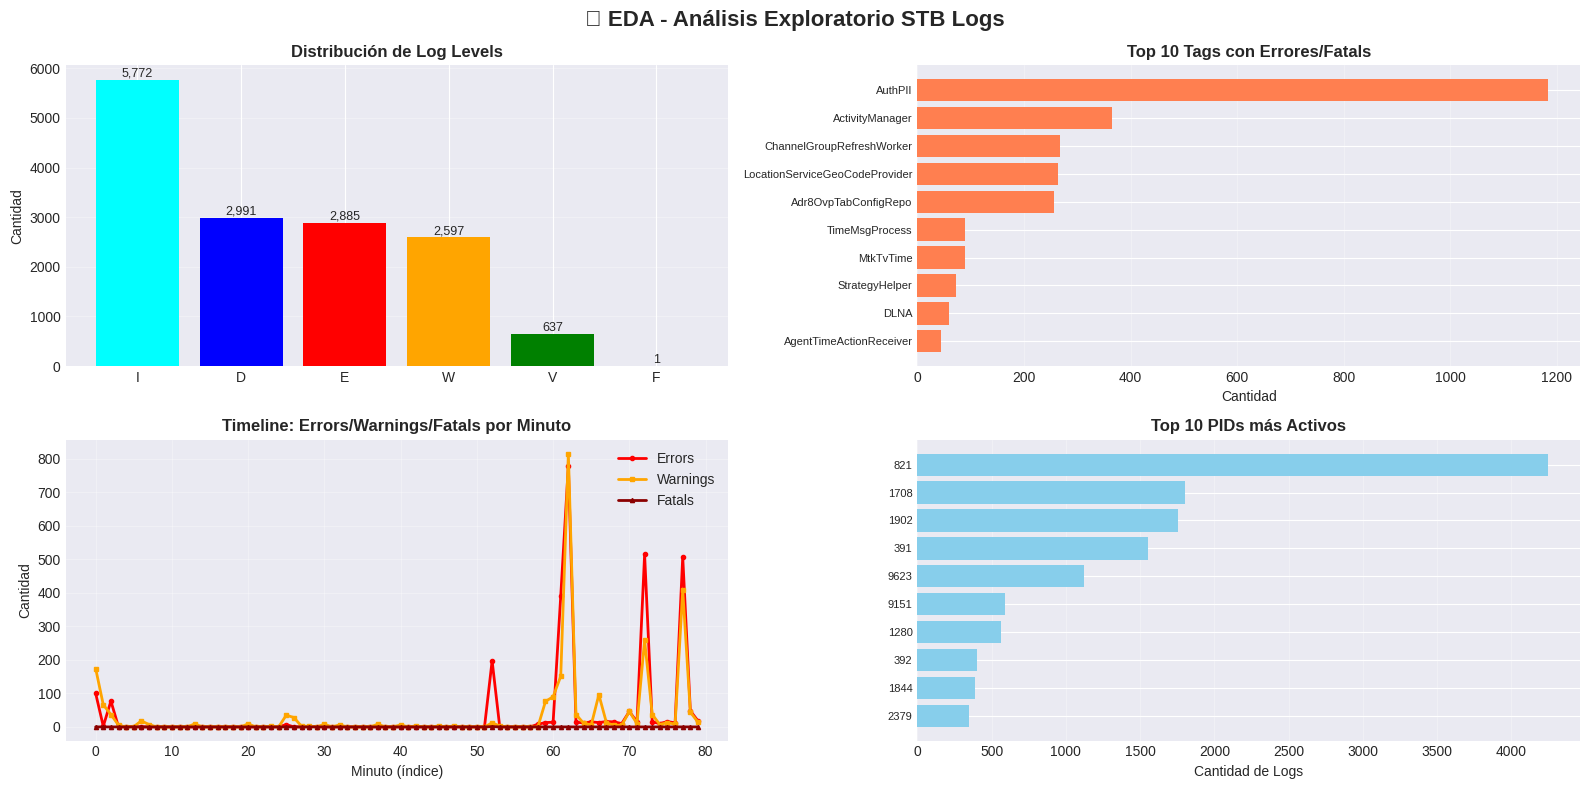

✅ Plot guardado: ../../data/plots02_features_timeline.png


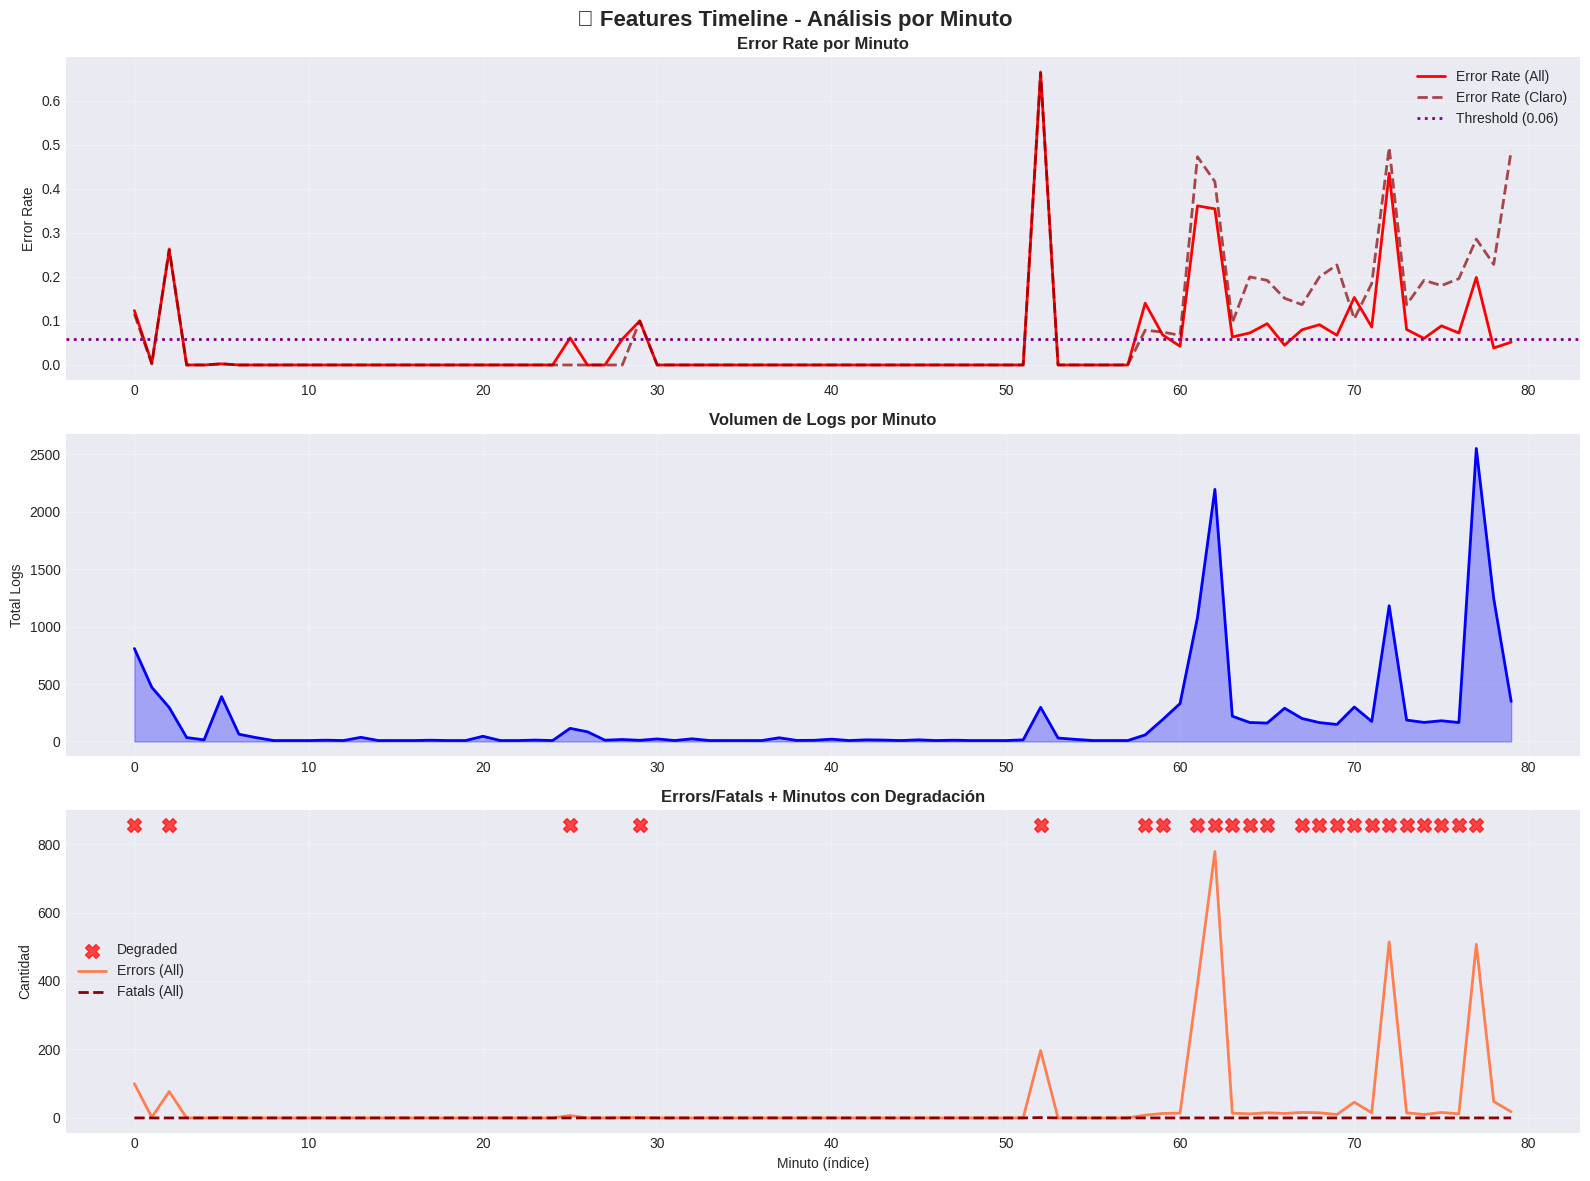

✅ Logs guardados: ../../data/processed_logs/stb_logs20260327_125750.csv
total de logs parseados: 14883
✅ Total de features: 42
Total reglas: 0
✅ Total de logs guardados: 14883


In [10]:

def main():
    if not Path(log_file).exists():
        print(f"Archivo no encontrado: {log_file}")
        return None, None, pd.DataFrame(), pd.DataFrame(), []
    
    parsed_logs = read_log_file(log_file)
    if parsed_logs is None:
        print("No se pudieron cargar los logs.")
        return None, None, pd.DataFrame(), pd.DataFrame(), []

    logs_by_minute = group_by_60s(parsed_logs)
    pids_claro = get_claro_pids(logs_by_minute)
    wef_results = counter_WEF(logs_by_minute, pids_claro)
    
    df = pd.DataFrame(parsed_logs)
    for col in ['device_model', 'firmware_version', 'android_version']:
        if col not in df.columns:
            df[col] = None
    df['is_error'] = df['level'] == 'E'
    df['is_warning'] = df['level'] == 'W'
    df['is_fatal'] = df['level'] == 'F'
    df['is_claro'] = df['pid'].isin(pids_claro)
    print(f"✅ DataFrame: {df.shape}")


    print(" Generando análisis de tops...")
    tops = generate_top_analysis(df, pids_claro)
    print_top_analysis(tops)
    

    features = aggregate_by_minute(df)
    features = calculate_rates(features)
    features = temporal_features(features)
    features = mark_degradation(features)
    print(f"✅ Features DataFrame: {features.shape}")
    print(f"✅ Total features: {len(features.columns)}")


    print(" Market Basket Analysis...")
    
    df_basket = create_basket_dataframe(logs_by_minute, pids_claro)
    freq_items, rules = apply_market_basket(df_basket, 
                                            min_support=MIN_SUPPORT,
                                            min_confidence=MIN_CONFIDENCE)
    
    if rules is not None and len(rules) > 0:
        print_association_rules(rules, top_n=5)
    
    # ========================================================================
    # 7. VISUALIZACIONES
    # ========================================================================
    print(" Generando visualizaciones...")

    plot_eda_overview(df, save=True)
    plot_features_timeline(features, save=True)
    if rules is not None and len(rules) > 0:
        plot_association_rules_viz(rules, save=True)


    #salvar resultados
    features_file = f"{OUTPUT_DIR}/stb_features{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv"
    features.to_csv(features_file, index=False)

    if rules is not None and len(rules) > 0:
        rules_file = f"{OUTPUT_DIR}/association_rules{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv"
        rules.to_csv(rules_file, index=False)
        print(f"✅ Reglas guardadas: {rules_file}")

    df_file = f"{OUTPUT_DIR}/stb_logs{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv"
    df.to_csv(df_file, index=False)
    print(f"✅ Logs guardados: {df_file}")
    print(f"total de logs parseados: {len(parsed_logs)}")
    print(f"✅ Total de features: {len(features.columns)}")
    print(f"Total reglas: {len(rules) if rules is not None else 0}") 
    print(f"✅ Total de logs guardados: {len(df)}") 



    return wef_results, df, features, rules

if __name__ == "__main__":
    results, df, features, rules = main() 
     

In [11]:
print("📊 Features DataFrame (primeras 15 filas):")
print(features.head(15))

print("\n📋 Columnas disponibles:")
print(features.columns.tolist())

print("\n📈 Estadísticas de Features Numéricas:")
print(features.describe())

📊 Features DataFrame (primeras 15 filas):
     time  total_logs  errors_all  warnings_all  fatals_all  claro_logs  \
0   12:53         809         100           174           0         795   
1   12:54         471           2            66           0         460   
2   12:55         295          77            37           0         292   
3   12:56          34           0             5           0          34   
4   12:57          14           0             0           0          14   
5   12:58         390           1             1           0         390   
6   12:59          63           0            18           0          63   
7   13:00          33           0             7           0          33   
8   13:01           8           0             0           0           8   
9   13:02           8           0             0           0           8   
10  13:03           8           0             0           0           8   
11  13:04          11           0             0           

In [12]:
def validate_eda(logs_list):
    """
    Valida si el EDA detecta diferencias entre Normal/Freeze/Lento.
    """
    results = []
    
    for path, name, categoria in logs_list:
        print(f"\n🔍 Procesando: {name}")
        
        global log_file
        log_file = path
        
        try:
            _, df, features, _ = main()
            
            # Métricas clave
            error_max = features['error_rate_all'].max() * 100
            warning_max = features['warning_rate_all'].max() * 100
            degraded = features['is_degraded'].sum()
            picos = len(features[features['errors_all'] > features['errors_all'].mean() + 2*features['errors_all'].std()])
            vol_std = features['volume_std'].mean()
            
            results.append({
                'nombre': name,
                'categoria': categoria,
                'error_max': error_max,
                'warning_max': warning_max,
                'degraded': degraded,
                'picos': picos,
                'vol_std': vol_std
            })
            
            print(f"✅ error_max={error_max:.1f}%, warning_max={warning_max:.1f}%, degraded={degraded}, picos={picos}")
            
        except Exception as e:
            print(f"❌ Error: {e}")
    
    # Crear DataFrame
    df_val = pd.DataFrame(results)
    
    # Análisis por categoría
    print("\n" + "="*80)
    print("📊 RESUMEN POR CATEGORÍA")
    print("="*80)
    
    for cat in df_val['categoria'].unique():
        subset = df_val[df_val['categoria'] == cat]
        print(f"\n{cat}:")
        print(f"  error_max:    {subset['error_max'].mean():.2f}%")
        print(f"  warning_max:  {subset['warning_max'].mean():.2f}%")
        print(f"  degraded:     {subset['degraded'].mean():.1f}")
        print(f"  picos:        {subset['picos'].mean():.1f}")
    
    # Conclusión
    print("\n" + "="*80)
    print("🎯 ¿EL EDA SIRVE?")
    print("="*80)
    
    normal = df_val[df_val['categoria'] == 'Normal']
    problemas = df_val[df_val['categoria'] != 'Normal']
    
    if len(normal) > 0 and len(problemas) > 0:
        ratio_error = problemas['error_max'].mean() / normal['error_max'].mean()
        ratio_picos = problemas['picos'].mean() / max(normal['picos'].mean(), 0.1)
        
        print(f"\nRatio Error Max (Problemas/Normal): {ratio_error:.2f}x")
        print(f"Ratio Picos (Problemas/Normal): {ratio_picos:.2f}x")
        
        if ratio_error > 1.5 or ratio_picos > 2:
            print("\n✅ SÍ SIRVE - Detecta diferencias significativas")
            print("👉 Puedes avanzar al MODELO")
        else:
            print("\n❌ NO SIRVE - No discrimina bien")
            print("👉 Necesitas ajustar features")
    
    return df_val


🔍 Procesando: STB_Normal_1
Minute: 14:17 - Errors All: 17, Errors Claro: 3, Fatals All: 0, Fatals Claro: 0
Minute: 14:17 - Warnings All: 777, Errors All: 17, Fatals All: 0, Warnings Claro: 520, Errors Claro: 3, Fatals Claro: 0
Minute: 14:18 - Errors All: 497, Errors Claro: 497, Fatals All: 0, Fatals Claro: 0
Minute: 14:18 - Warnings All: 3157, Errors All: 497, Fatals All: 0, Warnings Claro: 1051, Errors Claro: 497, Fatals Claro: 0
Minute: 14:19 - Errors All: 17, Errors Claro: 0, Fatals All: 0, Fatals Claro: 0
Minute: 14:19 - Warnings All: 429, Errors All: 17, Fatals All: 0, Warnings Claro: 99, Errors Claro: 0, Fatals Claro: 0
Minute: 14:20 - Errors All: 0, Errors Claro: 0, Fatals All: 0, Fatals Claro: 0
Minute: 14:20 - Warnings All: 373, Errors All: 0, Fatals All: 0, Warnings Claro: 65, Errors Claro: 0, Fatals Claro: 0
Minute: 14:21 - Errors All: 0, Errors Claro: 0, Fatals All: 0, Fatals Claro: 0
Minute: 14:21 - Warnings All: 303, Errors All: 0, Fatals All: 0, Warnings Claro: 4, Error

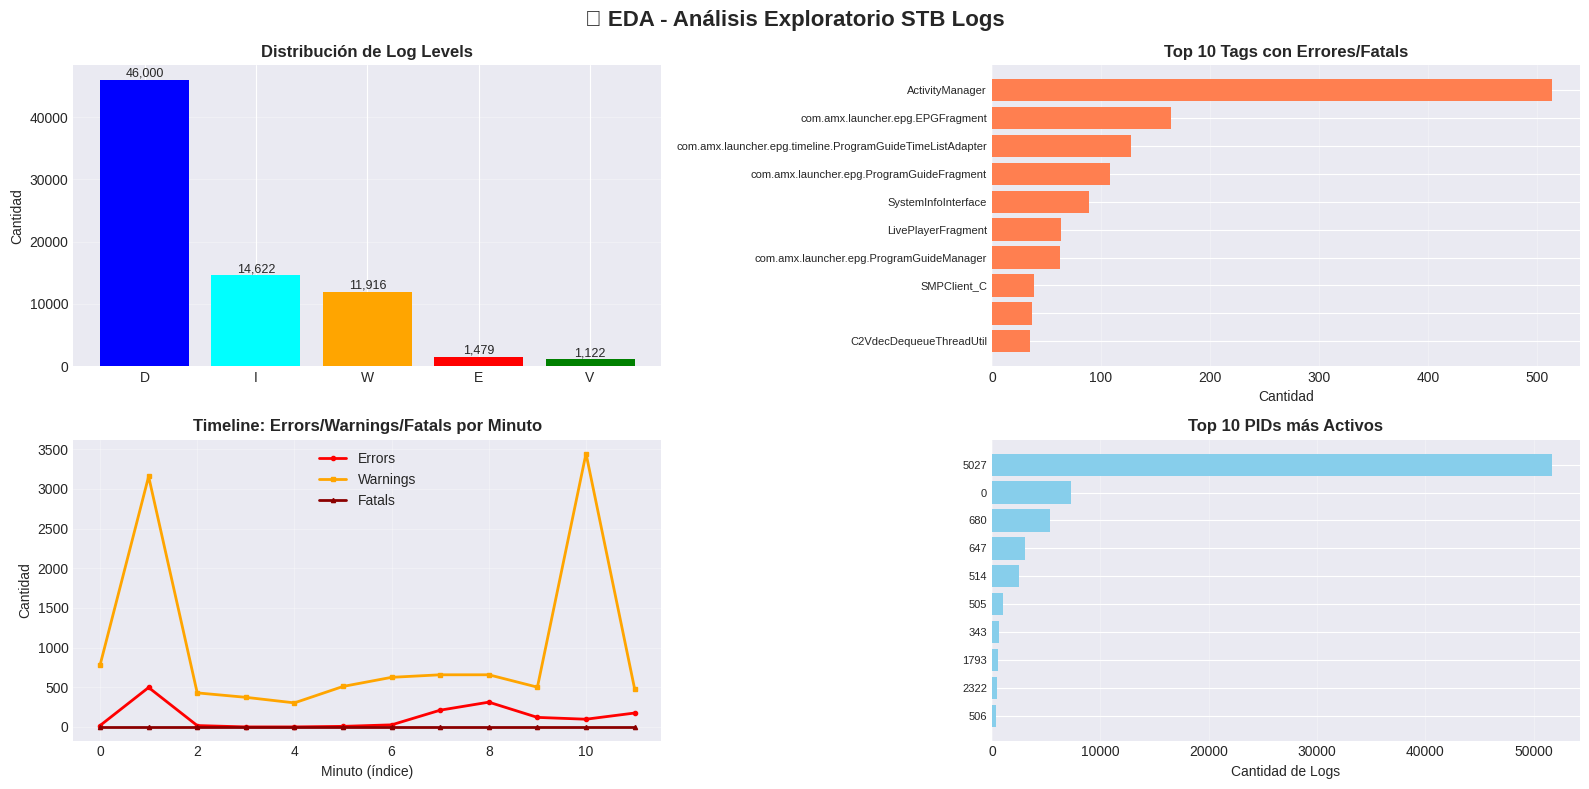

✅ Plot guardado: ../../data/plots02_features_timeline.png


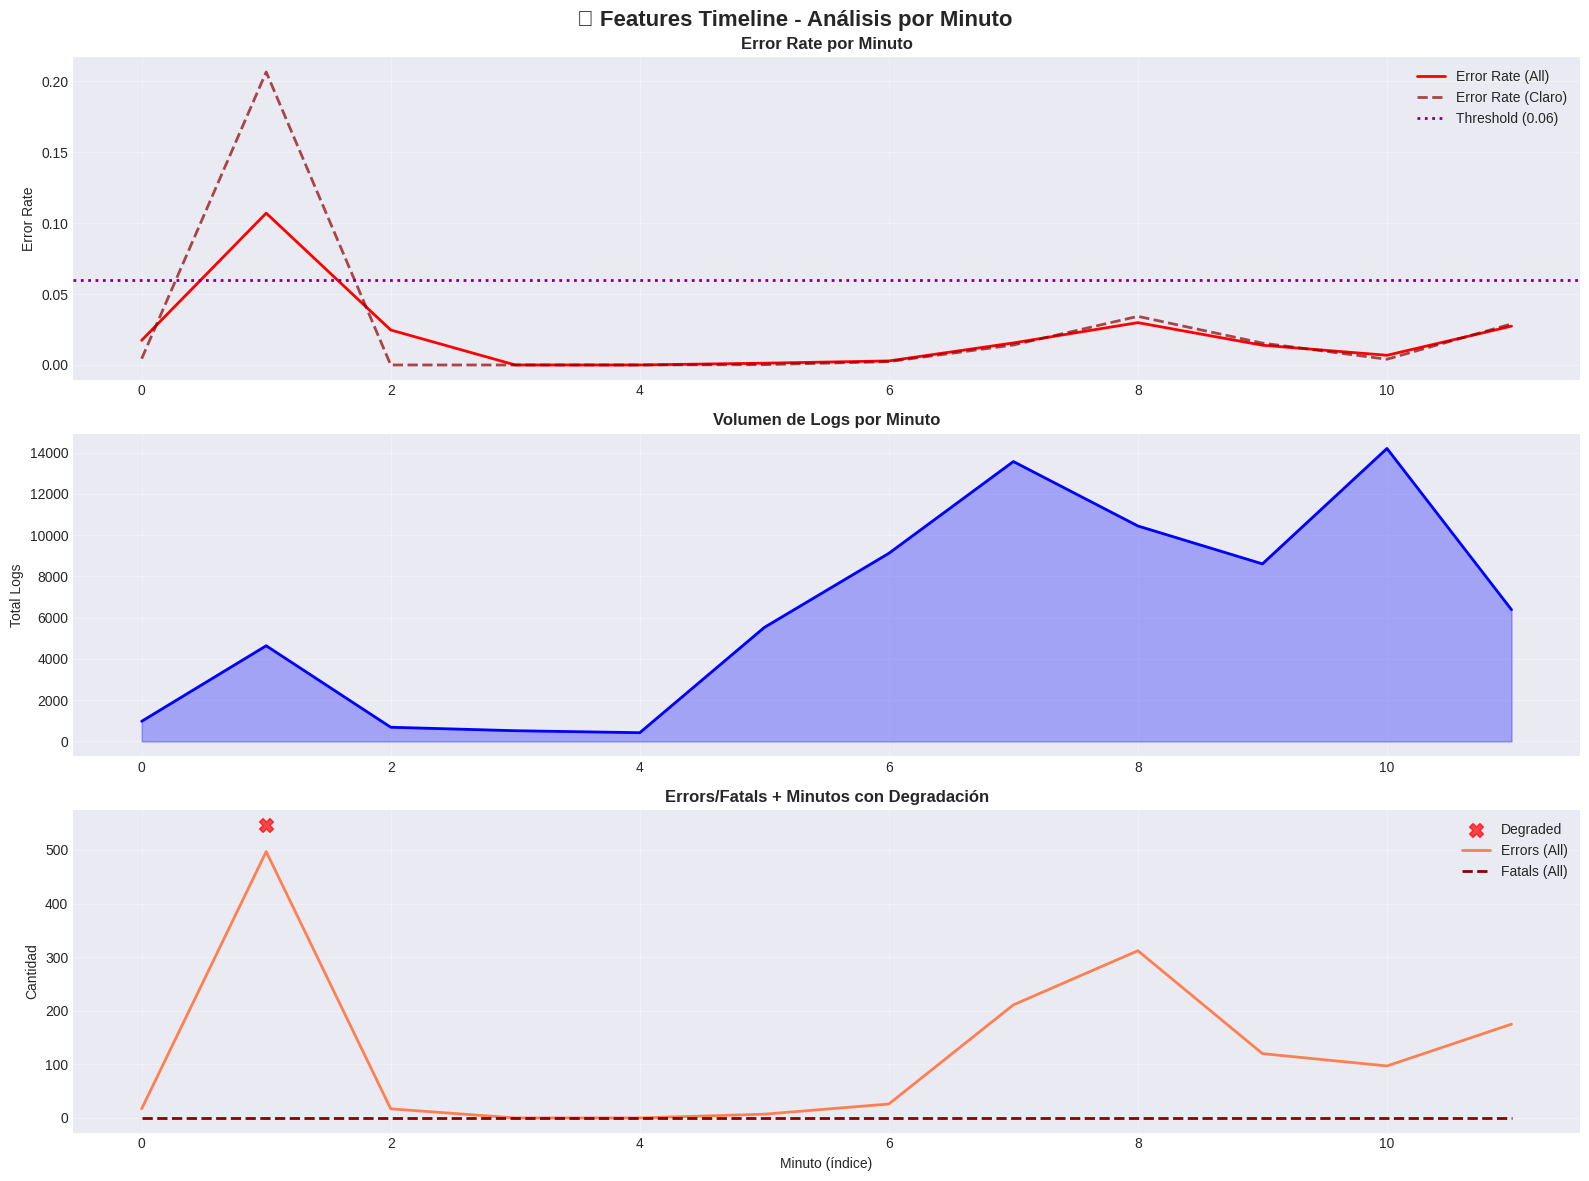

✅ Logs guardados: ../../data/processed_logs/stb_logs20260327_125756.csv
total de logs parseados: 75139
✅ Total de features: 42
Total reglas: 0
✅ Total de logs guardados: 75139
✅ error_max=10.7%, warning_max=79.4%, degraded=1, picos=1

🔍 Procesando: STB_Normal_2
Minute: 14:27 - Errors All: 20, Errors Claro: 5, Fatals All: 0, Fatals Claro: 0
Minute: 14:27 - Warnings All: 408, Errors All: 20, Fatals All: 0, Warnings Claro: 49, Errors Claro: 5, Fatals Claro: 0
Minute: 14:28 - Errors All: 1, Errors Claro: 0, Fatals All: 0, Fatals Claro: 0
Minute: 14:28 - Warnings All: 358, Errors All: 1, Fatals All: 0, Warnings Claro: 60, Errors Claro: 0, Fatals Claro: 0
Minute: 14:29 - Errors All: 19, Errors Claro: 0, Fatals All: 0, Fatals Claro: 0
Minute: 14:29 - Warnings All: 351, Errors All: 19, Fatals All: 0, Warnings Claro: 22, Errors Claro: 0, Fatals Claro: 0
Minute: 14:30 - Errors All: 7, Errors Claro: 0, Fatals All: 0, Fatals Claro: 0
Minute: 14:30 - Warnings All: 329, Errors All: 7, Fatals All: 0,

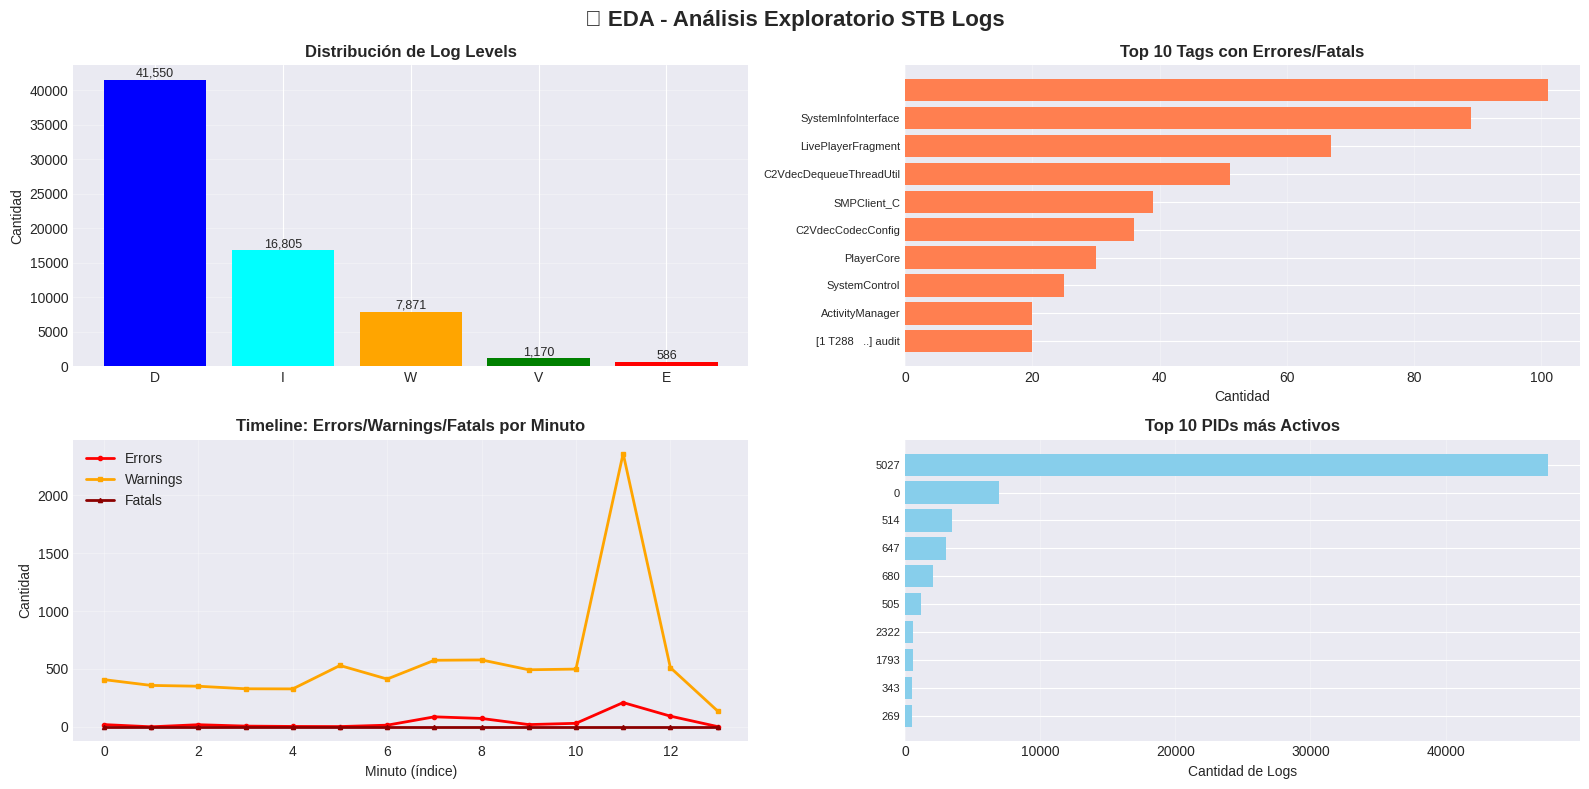

✅ Plot guardado: ../../data/plots02_features_timeline.png


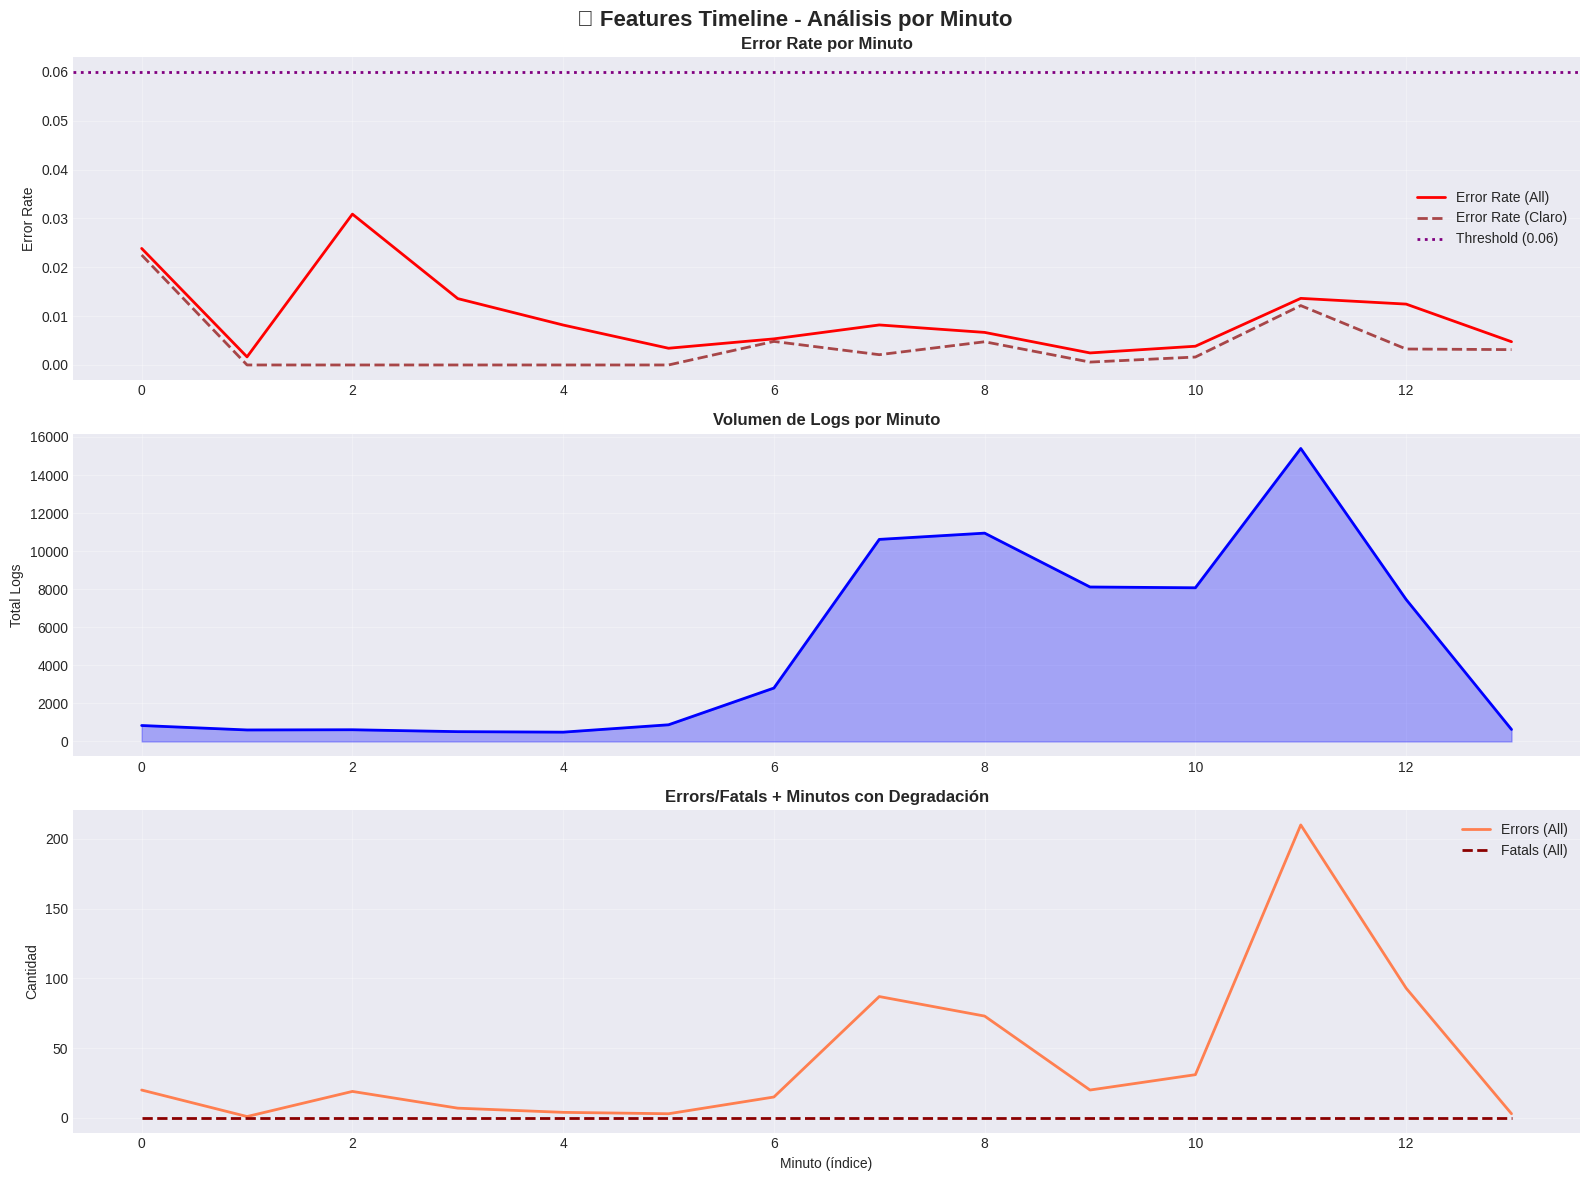

✅ Logs guardados: ../../data/processed_logs/stb_logs20260327_125801.csv
total de logs parseados: 67982
✅ Total de features: 42
Total reglas: 0
✅ Total de logs guardados: 67982
✅ error_max=3.1%, warning_max=67.1%, degraded=0, picos=1

🔍 Procesando: STB_Normal_3
Minute: 18:00 - Errors All: 89, Errors Claro: 77, Fatals All: 0, Fatals Claro: 0
Minute: 18:00 - Warnings All: 599, Errors All: 89, Fatals All: 0, Warnings Claro: 75, Errors Claro: 77, Fatals Claro: 0
Minute: 18:01 - Errors All: 984, Errors Claro: 919, Fatals All: 0, Fatals Claro: 0
Minute: 18:01 - Warnings All: 949, Errors All: 984, Fatals All: 0, Warnings Claro: 171, Errors Claro: 919, Fatals Claro: 0
Minute: 18:02 - Errors All: 933, Errors Claro: 923, Fatals All: 0, Fatals Claro: 0
Minute: 18:02 - Warnings All: 569, Errors All: 933, Fatals All: 0, Warnings Claro: 34, Errors Claro: 923, Fatals Claro: 0
Minute: 18:03 - Errors All: 365, Errors Claro: 322, Fatals All: 0, Fatals Claro: 0
Minute: 18:03 - Warnings All: 573, Errors Al

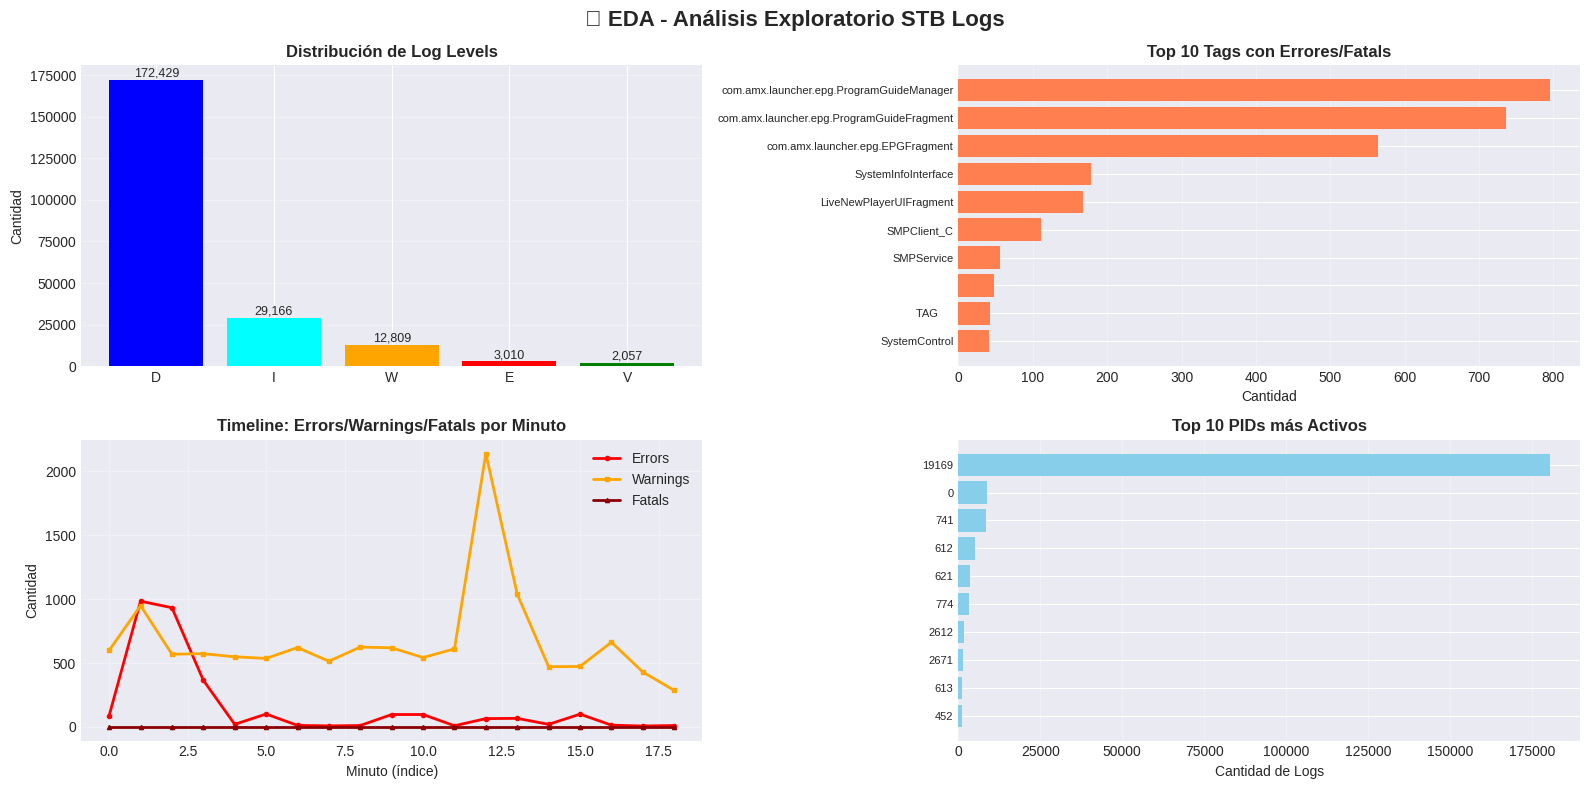

✅ Plot guardado: ../../data/plots02_features_timeline.png


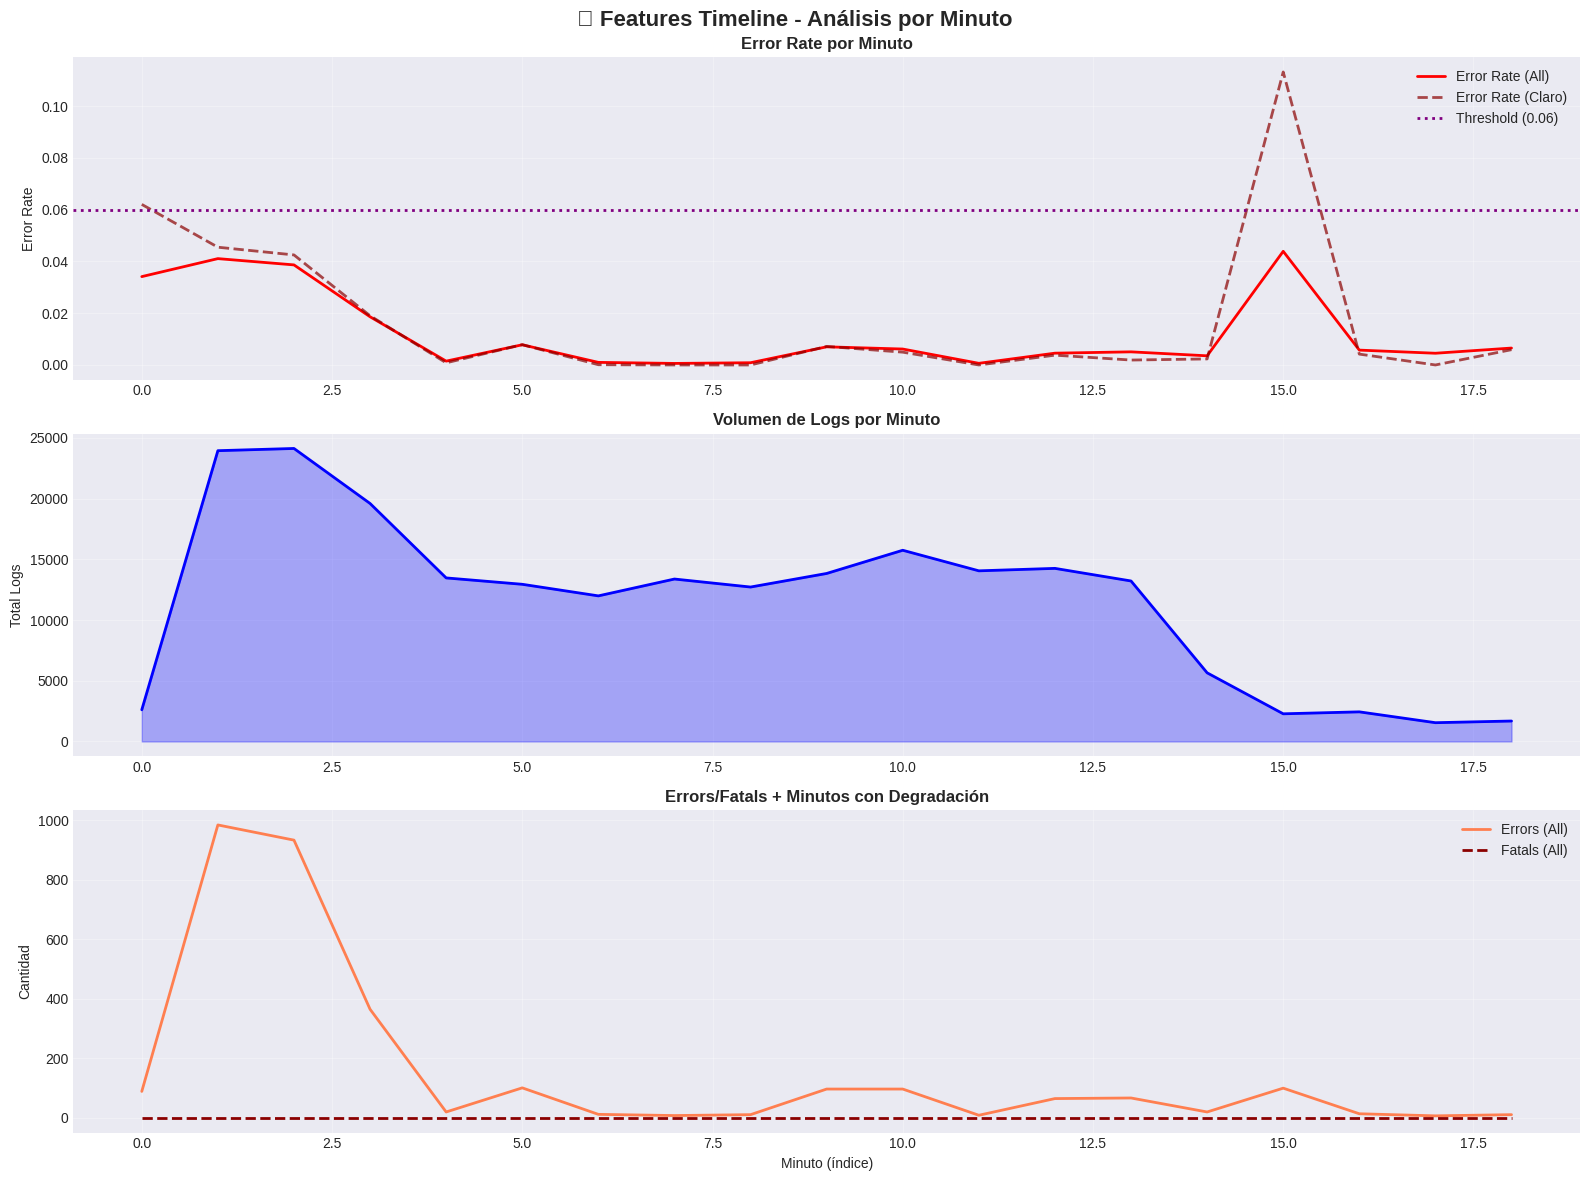

✅ Logs guardados: ../../data/processed_logs/stb_logs20260327_125811.csv
total de logs parseados: 219471
✅ Total de features: 42
Total reglas: 0
✅ Total de logs guardados: 219471
✅ error_max=4.4%, warning_max=27.8%, degraded=0, picos=2

🔍 Procesando: STB_Freeze
Minute: 18:30 - Errors All: 765, Errors Claro: 697, Fatals All: 0, Fatals Claro: 0
Minute: 18:30 - Warnings All: 1003, Errors All: 765, Fatals All: 0, Warnings Claro: 240, Errors Claro: 697, Fatals Claro: 0
Minute: 18:31 - Errors All: 1108, Errors Claro: 1100, Fatals All: 0, Fatals Claro: 0
Minute: 18:31 - Warnings All: 834, Errors All: 1108, Fatals All: 0, Warnings Claro: 113, Errors Claro: 1100, Fatals Claro: 0
Minute: 18:32 - Errors All: 825, Errors Claro: 790, Fatals All: 0, Fatals Claro: 0
Minute: 18:32 - Warnings All: 633, Errors All: 825, Fatals All: 0, Warnings Claro: 64, Errors Claro: 790, Fatals Claro: 0
Minute: 18:33 - Errors All: 30, Errors Claro: 13, Fatals All: 0, Fatals Claro: 0
Minute: 18:33 - Warnings All: 521, E

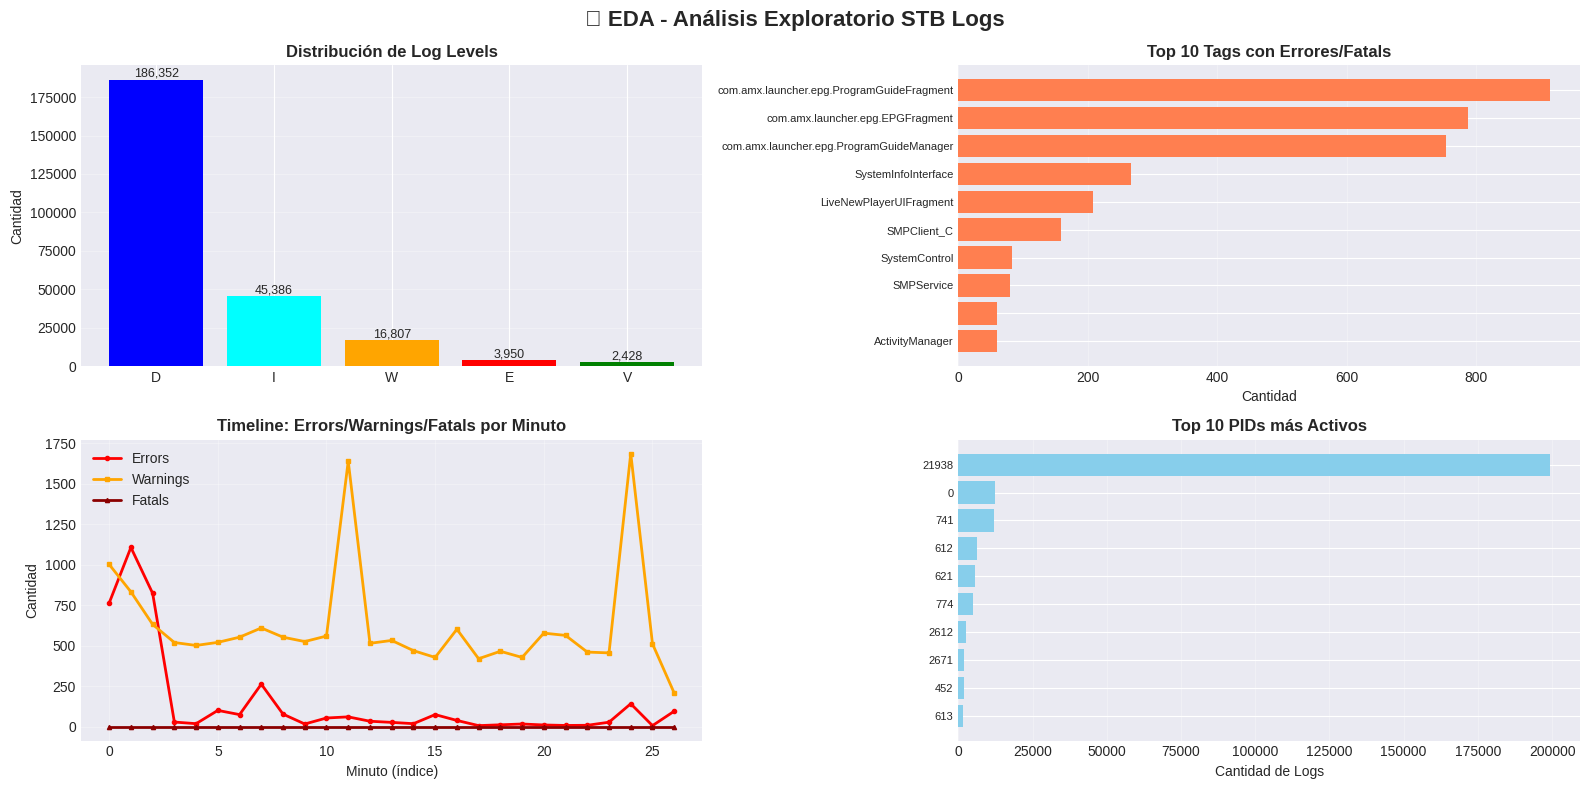

✅ Plot guardado: ../../data/plots02_features_timeline.png


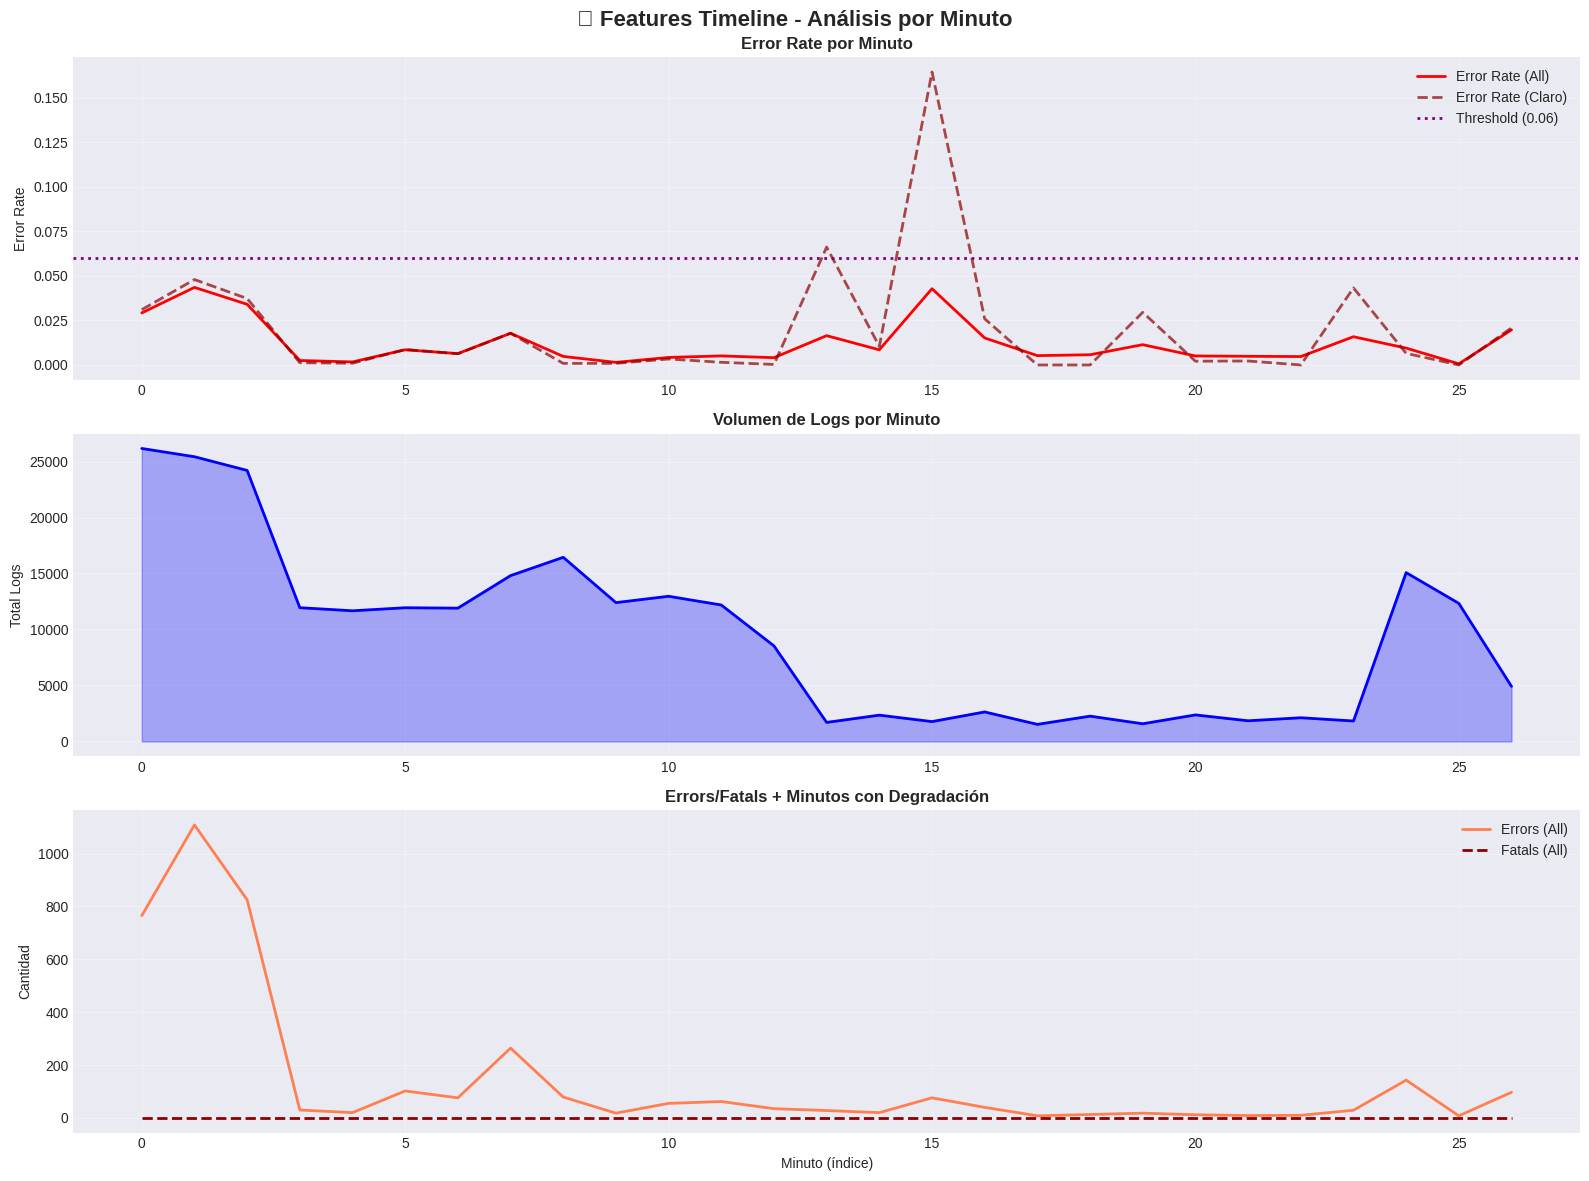

✅ Logs guardados: ../../data/processed_logs/stb_logs20260327_125824.csv
total de logs parseados: 254923
✅ Total de features: 42
Total reglas: 0
✅ Total de logs guardados: 254923
✅ error_max=4.4%, warning_max=31.4%, degraded=0, picos=3

📊 RESUMEN POR CATEGORÍA

Normal:
  error_max:    6.06%
  warning_max:  58.12%
  degraded:     0.3
  picos:        1.3

Freeze:
  error_max:    4.36%
  warning_max:  31.39%
  degraded:     0.0
  picos:        3.0

🎯 ¿EL EDA SIRVE?

Ratio Error Max (Problemas/Normal): 0.72x
Ratio Picos (Problemas/Normal): 2.25x

✅ SÍ SIRVE - Detecta diferencias significativas
👉 Puedes avanzar al MODELO


,nombre,categoria,error_max,warning_max,degraded,picos,vol_std
0,STB_Normal_1,Normal,10.708899,79.447853,1,1,2873.273614
1,STB_Normal_2,Normal,3.089431,67.075665,0,1,2188.245930
2,STB_Normal_3,Normal,4.391744,27.831715,0,2,4637.273092
3,STB_Freeze,Freeze,4.357230,31.393298,0,3,2940.280504


In [13]:
# Lista SOLO STB
logs = [
    # STB Normal
    ("/home/at1/Desktop/qa-predictive-analytics/data/raw_logs/stb/stb_logs_11-18.txt", "STB_Normal_1", "Normal"),
    ("/home/at1/Desktop/qa-predictive-analytics/data/raw_logs/stb/stb_logs_11-32.txt", "STB_Normal_2", "Normal"),
    ("/home/at1/Desktop/qa-predictive-analytics/data/raw_logs/stb/stb_logs_3_00_3_15.txt", "STB_Normal_3", "Normal"),
    
    # STB Freeze
    ("/home/at1/Desktop/qa-predictive-analytics/data/raw_logs/stb/stb_logs_3_30_3_55.txt", "STB_Freeze", "Freeze"),
]

# VALIDAR
df_validation = validate_eda(logs)

# Ver tabla
df_validation